In [1]:
import numpy as np
import matplotlib.pyplot as plt
import rioxarray as rxa

import sys
import os
scripts_dir = (os.path.dirname(os.getcwd()) + '/scripts/')
sys.path.append(scripts_dir)

from coherence import calc_coherence

In [2]:
# Create a 200x200 grid
shape = (200, 200)

# Simulate SAR amplitude (Rayleigh distributed-ish for natural terrain)
amp1 = np.random.rayleigh(scale=1.0, size=shape)
amp2 = np.random.rayleigh(scale=1.0, size=shape)

# Simulate SAR phase
# Background is totally random phase (0 coherence)
phase1 = np.random.uniform(-np.pi, np.pi, shape)
phase2 = np.random.uniform(-np.pi, np.pi, shape)

# Create a "stable" coherent feature in the center (e.g., a city or bare rock)
# We force the phase of image 2 to perfectly match image 1 in this square
phase2[50:150, 50:150] = phase1[50:150, 50:150]

# Construct the complex SLC arrays
slc1 = amp1 * np.exp(1j * phase1)
slc2 = amp2 * np.exp(1j * phase2)

print("Synthetic SLCs generated.")

Synthetic SLCs generated.


In [4]:
# Calculate using a 5x5 Boxcar (Uniform) filter
coh_uniform = calc_coherence(slc1, slc2, filter_type='uniform', window_size=(5, 5))

# Calculate using a Gaussian filter (sigma=2 usually approximates a 5x5 window's spread)
coh_gaussian = calc_coherence(slc1, slc2, filter_type='gaussian', sigma=2)

print("Coherence calculations complete.")

Coherence calculations complete.


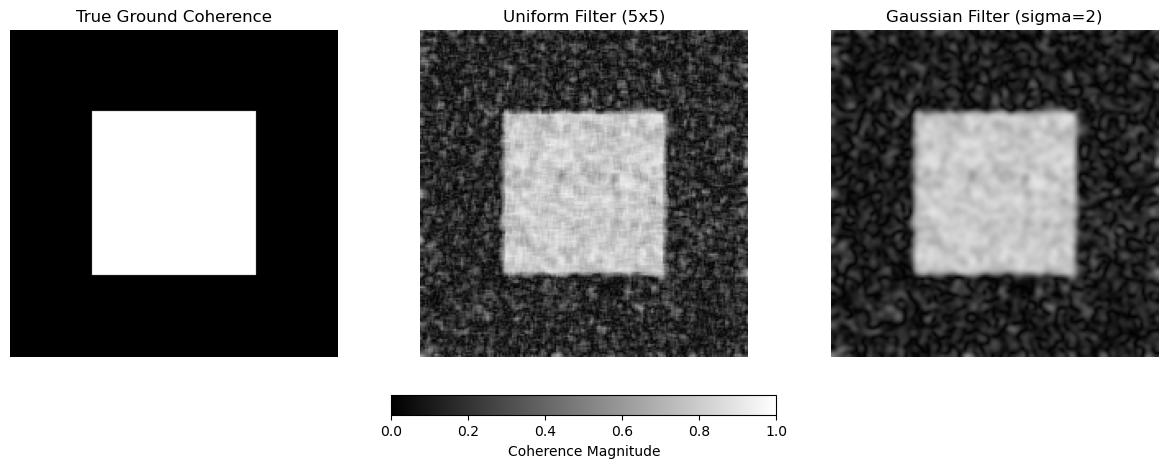

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# The actual ideal ground truth (1 in the middle, 0 on the outside)
true_coh = np.zeros(shape)
true_coh[50:150, 50:150] = 1.0

ax0 = axes[0].imshow(true_coh, cmap='gray', vmin=0, vmax=1)
axes[0].set_title('True Ground Coherence')
axes[0].axis('off')

# Uniform Filter Output
ax1 = axes[1].imshow(coh_uniform, cmap='gray', vmin=0, vmax=1)
axes[1].set_title('Uniform Filter (5x5)')
axes[1].axis('off')

# Gaussian Filter Output
ax2 = axes[2].imshow(coh_gaussian, cmap='gray', vmin=0, vmax=1)
axes[2].set_title('Gaussian Filter (sigma=2)')
axes[2].axis('off')

plt.colorbar(ax2, ax=axes, orientation='horizontal', fraction=0.05, pad=0.1, label='Coherence Magnitude')
plt.show()

# Running on real data

Take a "fast" glimpse at a full coherence file calculated over a flight. Runs in about 45 s for a 5 GB file. 

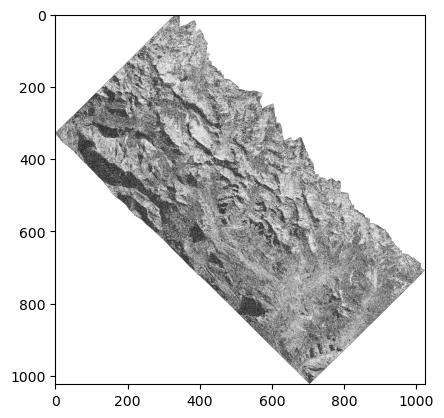

In [4]:
from osgeo import gdal

ds = gdal.Open('/bsuhome/julialober/scratch/coherence_data/uavsar_cohs/peeler/31619/peeler_31619_200212_200219_HH_s1_w7x10_int_coh.tif')
# Read at reduced resolution directly
buf_xsize, buf_ysize = 1024, 1024
arr = ds.GetRasterBand(1).ReadAsArray(
    buf_xsize=buf_xsize, buf_ysize=buf_ysize
)

import matplotlib.pyplot as plt
plt.imshow(arr, cmap='gray')
plt.show()

In [6]:
data_dir = '/bsuhome/julialober/scratch/coherence_data/uavsar_geoslcs/lowman/05208'
# img1 = f'{data_dir}/lowman_05208_20002_006_200131_L090HH_01_BU_s1_2x8.slc.complex.tif'
# img2 = f'{data_dir}/lowman_05208_20007_002_200213_L090HH_01_BU_s1_2x8.slc.complex.tif'
img1 = f'{data_dir}/lowman_05208_21015_009_210303_L090HH_01_BU_s1_2x8.slc.complex.tif'
img2 = f'{data_dir}/lowman_05208_21017_019_210310_L090HH_01_BU_s1_2x8.slc.complex.tif'
data_dir = '/bsuhome/julialober/scratch/coherence_data/uavsar_geoslcs_cropped/stlake/27129'
img1 = f'{data_dir}/stlake_27129_21020_024_210316_L090VV_01_BC_s1_1x1.slc.complex_cropped.tif'
img2 = f'{data_dir}/stlake_27129_21022_001_210322_L090VV_01_BC_s1_1x1.slc.complex_cropped.tif'

In [7]:
coh_gaus = calc_coherence(img1, img2, filter_type='gaussian')
coh_uni = calc_coherence(img1, img2, filter_type='uniform')

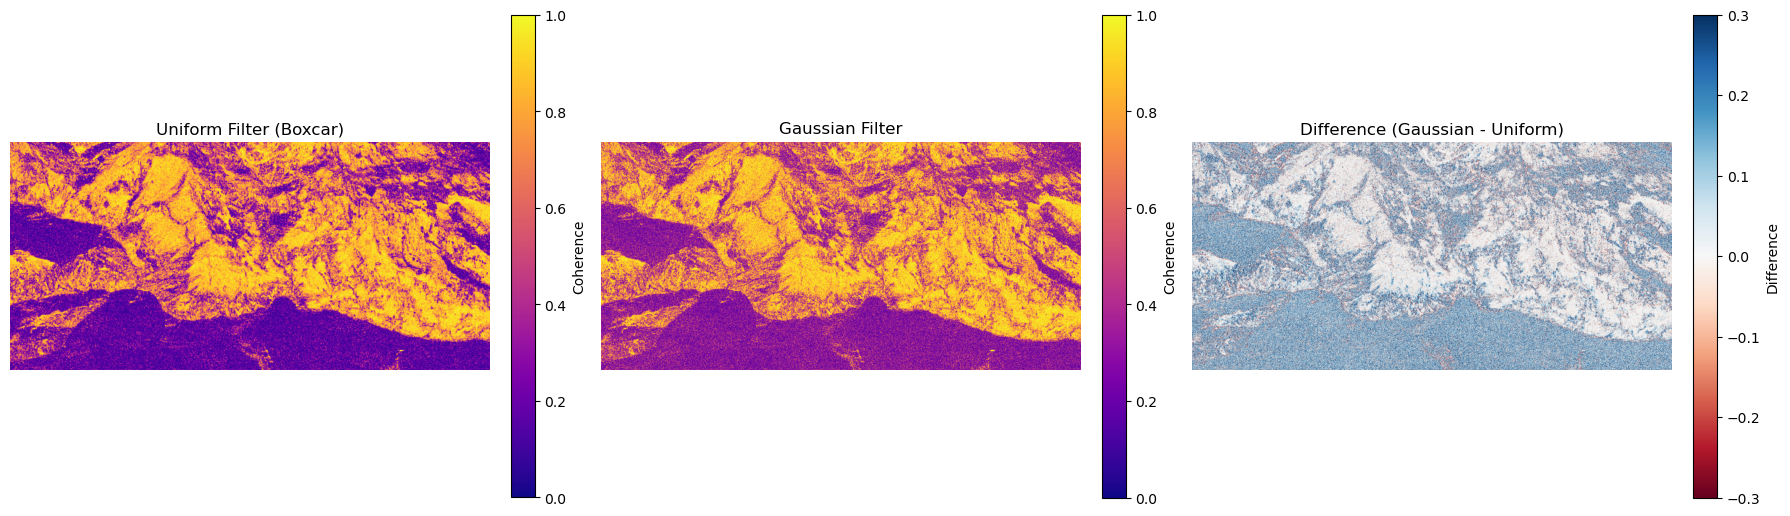

In [8]:
# Set a downsampling factor to speed up plotting (e.g., 10 means take every 10th pixel)
factor = 1

# 2. Downsample the arrays for lightning-fast plotting using NumPy slicing
coh_gaus_plot = coh_gaus[::factor, ::factor]
coh_uni_plot = coh_uni[::factor, ::factor]

# Create a wide figure to fit three panels comfortably
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- Panel 1: Uniform Coherence ---
# Standard SAR coherence is almost always plotted in grayscale from 0 to 1
im0 = axes[0].imshow(coh_uni_plot, cmap='plasma', vmin=0, vmax=1)
axes[0].set_title('Uniform Filter (Boxcar)')
axes[0].axis('off')
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04, label='Coherence')

# --- Panel 2: Gaussian Coherence ---
im1 = axes[1].imshow(coh_gaus_plot, cmap='plasma', vmin=0, vmax=1)
axes[1].set_title('Gaussian Filter')
axes[1].axis('off')
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04, label='Coherence')

# --- Panel 3: Difference Map ---
# Gaussian minus Uniform
diff = coh_gaus_plot - coh_uni_plot

# Calculate a symmetric limit for the colorbar so white is exactly zero
# We clip it at 0.3 just in case there are wild outliers, keeping the colors punchy
v_limit = min(np.nanmax(np.abs(diff)), 0.3) 

# 'RdBu' (Red-White-Blue) is perfect here. 
# Red means Gaussian is higher, Blue means Uniform is higher, White means they match.
im2 = axes[2].imshow(diff, cmap='RdBu', vmin=-v_limit, vmax=v_limit)
axes[2].set_title('Difference (Gaussian - Uniform)')
axes[2].axis('off')
fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04, label='Difference')

plt.tight_layout()
plt.show()

In [22]:
jpl_fp = '/bsuhome/julialober/scratch/coherence_data/jpl_products/lowman_05208_21015-009_21017-019_0007d_s01_L090HH_01.cor.grd.tiff'
jpl_fp = '/bsuhome/julialober/scratch/coherence_data/jpl_products/stlake_27129_21020-024_21022-001_0006d_s01_L090VV_01.cor.grd'
jpl_fp_ann = '/bsuhome/julialober/scratch/coherence_data/jpl_products/stlake_27129_21020-024_21022-001_0006d_s01_L090VV_01.ann'

jpl_url = 'https://uavsar.asf.alaska.edu/UA_stlake_27129_21020-024_21022-001_0006d_s01_L090_01/stlake_27129_21020-024_21022-001_0006d_s01_L090VV_01.cor.grd'

In [23]:
from uavsar_pytools import UavsarImage

# Initialize scene pointing to your .grd file directory
# uavsar_pytools automatically looks for the matching .ann file in the same folder
scene = UavsarImage(url = jpl_url, work_dir='/bsuhome/julialober/scratch/coherence_data/jpl_products/')
scene.download()
scene.convert_to_tiff()

Exception: Input file path: /bsuhome/julialober/scratch/coherence_data/jpl_products/bin_imgs/stlake_27129_21020-024_21022-001_0006d_s01_L090VV_01.cor.grd does not exist.

In [9]:
# convert coh_gaus to a spatial data array 
coh_spat = rxa.open_rasterio(img1).squeeze()
# coh_spat.real.plot()
coh_gaus = calc_coherence(img1, img2, 
                                     window_size=(20,20),
                                     filter_type='gaussian')
coh_gaus_spat = coh_spat.copy(data=coh_gaus)
# print(coh_gaus_spat)
coh_gaus_spat = coh_gaus_spat.where(coh_gaus_spat <= 1)

coh_jpl = rxa.open_rasterio(jpl_fp)
jpl_matched = coh_jpl.rio.reproject_match(coh_gaus_spat)
jpl_matched = jpl_matched.where(coh_gaus_spat.notnull())
coh_gaus_spat = coh_gaus_spat.where(jpl_matched.notnull())
jpl_matched

<xarray.DataArray (band: 1, y: 6729, x: 9976)> Size: 269MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]],
      shape=(1, 6729, 9976), dtype=float32)
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 54kB 43.97 43.97 43.97 43.97 ... 43.59 43.59 43.59
  * x            (x) float64 80kB -116.3 -116.3 -116.3 ... -115.8 -115.8 -115.8
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0
    _FillValue:     nan

In [10]:
# coh_spat.real.plot()
coh_uni = calc_coherence(img1, img2, 
                                     window_size=(20,20),
                                     filter_type='uniform')
coh_uni_spat = coh_spat.copy(data=coh_uni)
# print(coh_gaus_spat)
coh_uni_spat = coh_uni_spat.where(coh_uni_spat <= 1)
coh_uni_spat = coh_uni_spat.where(jpl_matched.notnull())

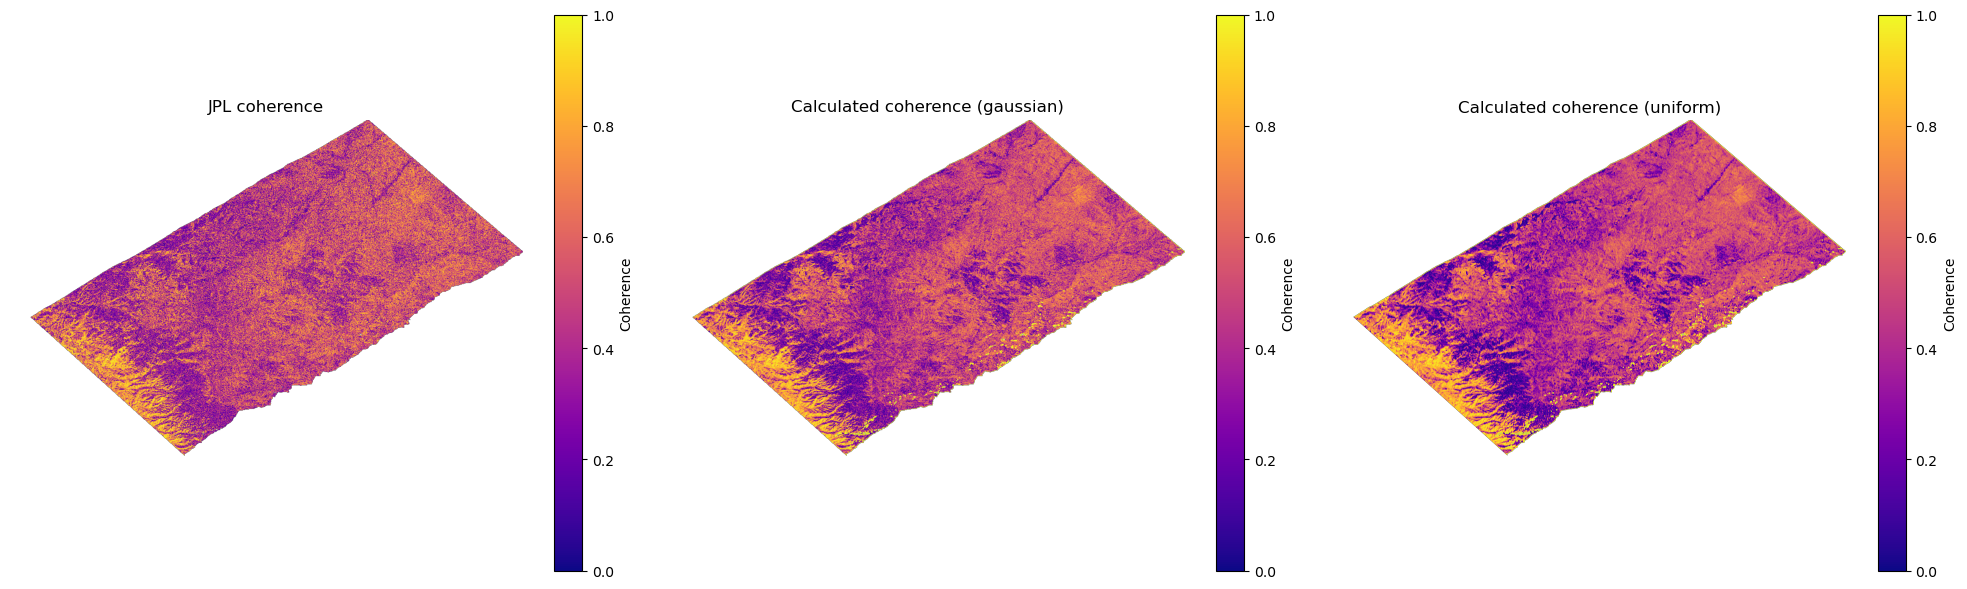

In [11]:
# Set a downsampling factor to speed up plotting (e.g., 10 means take every 10th pixel)
factor = 10

# 2. Downsample the arrays for lightning-fast plotting using NumPy slicing
jpl_plot_data = jpl_matched.squeeze().values[::factor, ::factor]
coh_plot_data = coh_gaus_spat.squeeze().values[::factor, ::factor]
coh2_plot_data = coh_uni_spat.squeeze().values[::factor, ::factor]

# 3. Generate the plots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))

jpl_plot = ax1.imshow(jpl_plot_data, vmin=0, vmax=1, cmap='plasma')
ax1.set_title(f"JPL coherence")
fig.colorbar(jpl_plot, ax=ax1, label='Coherence')
ax1.axis('off') 

coh_plot = ax2.imshow(coh_plot_data, vmin=0, vmax=1, cmap='plasma')
ax2.set_title(f"Calculated coherence (gaussian)")
fig.colorbar(coh_plot, ax=ax2, label='Coherence')
ax2.axis('off')

# Assuming you have both loaded as xarray DataArrays or numpy arrays
diff_map = jpl_plot_data - coh_plot_data

# diff_plot = ax3.imshow(diff_map, cmap='coolwarm')
coh2_plot = ax3.imshow(coh_uni_spat, vmin=0, vmax=1, cmap='plasma')
ax3.set_title(f"Calculated coherence (uniform)")
fig.colorbar(coh2_plot, ax=ax3, label='Coherence')
ax3.axis('off')

plt.tight_layout()
plt.show()

r-squared (gaus) = 0.097
rmse (gaus) = 0.209
r-squared (uni) = -0.019
rmse (uni) = 0.222


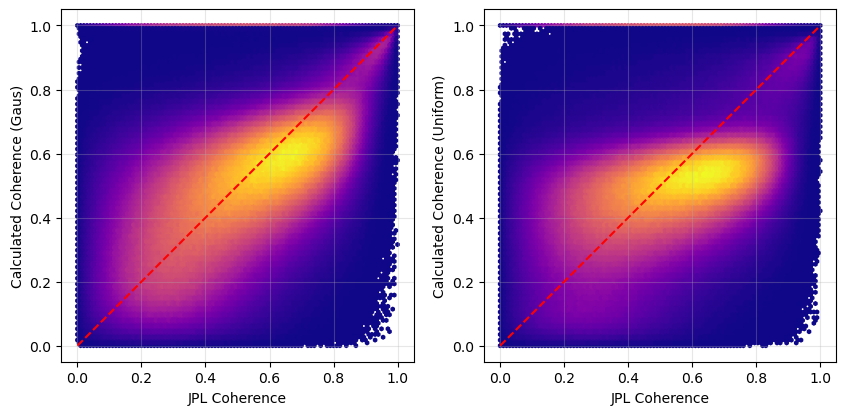

In [12]:
# 1. Flatten your arrays to 1D
jpl_flat = jpl_matched.values.flatten()
calc_flat = coh_gaus_spat.values.flatten() # Or whatever your calculated variable is named
calc_uni = coh_uni_spat.values.flatten()

# 2. Mask out the NaNs (Crucial! hist2d will break or look weird with NaNs)
valid_mask = ~np.isnan(jpl_flat) & ~np.isnan(calc_flat)
x = jpl_flat[valid_mask]
y = calc_flat[valid_mask]
y2 = calc_uni[valid_mask]

# 3. Generate the Density Heatmap
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 6))

# bins=100 divides the data into a 100x100 grid. 
# cmin=1 ensures that bins with 0 points remain transparent/white instead of colored
h = ax1.hexbin(x, y, bins=200, cmap='plasma', mincnt=1)
ax1.set_aspect('equal')
h = ax2.hexbin(x, y2, bins=200, cmap='plasma', mincnt=1)
ax2.set_aspect('equal')

# Add a colorbar to show what the colors represent
# plt.colorbar(h[3], label='Number of Pixels')

# 4. Add a 1:1 reference line
# Since you are comparing to a "gold standard", this line shows where a perfect match would be
min_val = min(np.nanmin(x), np.nanmin(y))
max_val = max(np.nanmax(x), np.nanmax(y))
ax1.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=1.5)
ax2.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=1.5)

# Formatting
ax1.set_xlabel('JPL Coherence')
ax1.set_ylabel('Calculated Coherence (Gaus)')
ax1.grid(alpha=0.3)

ax2.set_xlabel('JPL Coherence')
ax2.set_ylabel('Calculated Coherence (Uniform)')
ax2.grid(alpha=0.3)

# Source - https://stackoverflow.com/a/64902907
# Posted by John Jack Lewis
# Retrieved 2026-03-28, License - CC BY-SA 4.0
from sklearn.metrics import r2_score, root_mean_squared_error 
print("r-squared (gaus) = {:.3f}".format(r2_score(x, y)))
print("rmse (gaus) = {:.3f}".format(root_mean_squared_error(x, y)))
print("r-squared (uni) = {:.3f}".format(r2_score(x, y2)))
print("rmse (uni) = {:.3f}".format(root_mean_squared_error(x, y2)))

# plt.title('Coherence comparison (Density)')
# plt.grid(alpha=0.3)

plt.show()

## Coherence grid size tracking 



In [13]:
data_dir = '/bsuhome/julialober/scratch/coherence_data/'
sample_info = {
    'loc':'stlake', 
    'flight_no': '27129', 
    'date': '210310',
    'dim': '1x1'
    }

In [14]:
import re
import numpy as np

def parse_annotation_spacing(ann_path):
    """Parses the .ann file to extract native SLC pixel spacing and dimensions."""
    metadata = {}
    with open(ann_path, 'r') as f:
        content = f.read()
    
        
    # Extract row/column spacing
    metadata['azimuth_spacing'] = float(re.search(r'1x1 SLC Azimuth Pixel Spacing\s*\(m\)\s*=\s*([\d\.]+)', content).group(1))
    metadata['range_spacing'] = float(re.search(r'1x1 SLC Range Pixel Spacing\s*\(m\)\s*=\s*([\d\.]+)', content).group(1))
    
    # Extract dimensions (e.g., rows and columns for 1x1 SLC)
    metadata['slc_rows'] = int(re.search(r'slc_1_1x1_mag\.set_rows\s*\(pixels\)\s*=\s*(\d+)', content).group(1))
    metadata['slc_cols'] = int(re.search(r'slc_1_1x1_mag\.set_cols\s*\(pixels\)\s*=\s*(\d+)', content).group(1))
    
    return metadata

# Trace native grid
fname = data_dir + \
    f"uavsar_slcs/{sample_info['loc']}/{sample_info['flight_no']}/" + \
    f"{sample_info['loc']}_{sample_info['flight_no']}_21018_002_{sample_info['date']}_L090VV_01_BC.ann"
print(fname)
slc_meta = parse_annotation_spacing(fname)
print(f"--- Step 1: Native 1x1 SLC Grid ---")
print(f"Pixel Spacing (Azimuth x Slant Range): {slc_meta['azimuth_spacing']:.2f} m x {slc_meta['range_spacing']:.2f} m")
print(f"Array Dimensions (Rows x Cols): {slc_meta['slc_rows']} x {slc_meta['slc_cols']}")

/bsuhome/julialober/scratch/coherence_data/uavsar_slcs/stlake/27129/stlake_27129_21018_002_210310_L090VV_01_BC.ann
--- Step 1: Native 1x1 SLC Grid ---
Pixel Spacing (Azimuth x Slant Range): 0.60 m x 1.67 m
Array Dimensions (Rows x Cols): 53744 x 9360


In [15]:
def trace_llh_resolution(ann_path, slc_meta):
    with open(ann_path, 'r') as f:
        content = f.read()
    
    # Read LLH-specific array dimensions
    llh_rows = int(re.search(r'llh_1_2x8\.set_rows\s*\(pixels\)\s*=\s*(\d+)', content).group(1))
    llh_cols = int(re.search(r'llh_1_2x8\.set_cols\s*\(pixels\)\s*=\s*(\d+)', content).group(1))
    
    # Compute the downsampled pixel spacing
    llh_azimuth_spacing = slc_meta['azimuth_spacing'] * 8
    llh_range_spacing = slc_meta['range_spacing'] * 2
    
    print(f"--- Step 2: Native 2x8 LLH Coordinate Grid ---")
    print(f"Array Dimensions (Rows x Cols): {llh_rows} x {llh_cols}")
    print(f"LLH Coordinate Spacing: {llh_azimuth_spacing:.2f} m (Az) x {llh_range_spacing:.2f} m (Range)")

trace_llh_resolution(fname, slc_meta)

--- Step 2: Native 2x8 LLH Coordinate Grid ---
Array Dimensions (Rows x Cols): 6718 x 4680
LLH Coordinate Spacing: 4.80 m (Az) x 3.33 m (Range)


In [16]:
# During interpolation, verify your coordinate array shapes match the SLC:
# lat_interpolated.shape == (slc_rows, slc_cols)
# lon_interpolated.shape == (slc_rows, slc_cols)
print(f"--- Step 3: Interpolated Grid Verification ---")
print(f"Targeting 1x1 density: {slc_meta['slc_rows']} rows x {slc_meta['slc_cols']} columns")

--- Step 3: Interpolated Grid Verification ---
Targeting 1x1 density: 53744 rows x 9360 columns


In [17]:
import rioxarray

def trace_geotiff_resolution(tif_path):
    # Load geocoded raster
    da = rioxarray.open_rasterio(tif_path)
    da = da.rio.write_crs('EPSG:4326')

    crs = da.rio.crs
    res_x, res_y = da.rio.resolution()
    
    print(f"--- Step 4: Geocoded GeoTIFF Spacing ---")
    print(f"Coordinate Reference System (CRS): {crs}")
    print(f"Pixel spacing in coordinate units: {abs(res_x)} x {abs(res_y)}")
    
    # If EPSG:4326, convert degrees to meters
    if crs.to_epsg() == 4326:
        # Approximate at mean latitude of your scene
        mean_lat = da.y.mean().values
        meters_per_deg_lat = 111132.05  # m/deg at equator
        meters_per_deg_lon = 111321.3 * np.cos(np.radians(mean_lat))
        
        spacing_y_m = abs(res_y) * meters_per_deg_lat
        spacing_x_m = abs(res_x) * meters_per_deg_lon
        print(f"Approximate Pixel Spacing in Meters at Lat {mean_lat:.2f}°: {spacing_x_m:.2f} m (Lon) x {spacing_y_m:.2f} m (Lat)")
        
        # Reproject to UTM to verify exact metric coordinates
        da_utm = da.rio.reproject(da.rio.estimate_utm_crs())
        utm_res_x, utm_res_y = da_utm.rio.resolution()
        print(f"Projected UTM Resolution: {abs(utm_res_x):.2f} m x {abs(utm_res_y):.2f} m")
    else:
        print(f"Metric Grid Spacing: {abs(res_x):.2f} m x {abs(res_y):.2f} m")
        
    print(f"Data array shape: {da.shape}")
    return da

geo_fname = data_dir + \
    f"uavsar_geoslcs_cropped/{sample_info['loc']}/{sample_info['flight_no']}/" + \
    f"{sample_info['loc']}_{sample_info['flight_no']}_21018_002_{sample_info['date']}_L090VV_01_BC_s1_{sample_info['dim']}.slc.complex_cropped.tif"
coh_fname = data_dir + \
    f"uavsar_cohs_cropped/{sample_info['loc']}/{sample_info['flight_no']}/" + \
    f"{sample_info['loc']}_{sample_info['flight_no']}_{sample_info['date']}_HV-VH_s1_w3x12_crosspol_coh.tif"

# Trace both geocoded and cropped tifs using this helper function
da_geocoded = trace_geotiff_resolution(geo_fname)
da_cropped = trace_geotiff_resolution(coh_fname)

--- Step 4: Geocoded GeoTIFF Spacing ---
Coordinate Reference System (CRS): EPSG:4326
Pixel spacing in coordinate units: 7.645205171249158e-06 x 7.644188168097377e-06
Approximate Pixel Spacing in Meters at Lat 40.60°: 0.65 m (Lon) x 0.85 m (Lat)


/bsuhome/julialober/miniforge3/envs/coherence_v2/lib/python3.11/site-packages/rasterio/warp.py:387: ComplexWarning: Casting complex values to real discards the imaginary part
  dest = _reproject(


Projected UTM Resolution: 0.69 m x 0.69 m
Data array shape: (1, 2957, 6205)
--- Step 4: Geocoded GeoTIFF Spacing ---
Coordinate Reference System (CRS): EPSG:4326
Pixel spacing in coordinate units: 7.645205171249158e-06 x 7.644188168097377e-06
Approximate Pixel Spacing in Meters at Lat 40.60°: 0.65 m (Lon) x 0.85 m (Lat)
Projected UTM Resolution: 0.69 m x 0.69 m
Data array shape: (1, 2957, 6205)
